Pré-ambulo

In [1]:
#### Bibliotecas
from datetime import datetime
from dateutil.relativedelta import relativedelta
from functools import partial

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from darts import TimeSeries
from darts.models import NaiveDrift,ExponentialSmoothing,AutoARIMA,Theta,NBEATSModel,NHiTSModel,PatchTSTFMModel
from sklearn.model_selection import TimeSeriesSplit
from darts.metrics import mae, mse, mape, smape
#from statsforecast import StatsForecast
#from statsforecast.models import AutoARIMA, AutoETS, Naive, SeasonalNaive, Theta
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.formula.api as smf
#from utilsforecast.evaluation import evaluate
#from utilsforecast.losses import mae, mape, mase, mse, smape


c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

Carrega a base e cria os Dataframes

In [3]:
base = pd.read_excel(
    r'C:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\CONSUMO_MENSAL_DE_ENERGIA_ELÉTRICA_POR_CLASSE.xlsx',
    sheet_name=None
)

#### Intervalo de tempo da série temporal
ultima_atualizacao = datetime.strptime(base['TOTAL'].iloc[18, 0][41:48], '%Y-%m')
ultima_atualizacao = ultima_atualizacao - relativedelta(months=1)
inicio_serie = datetime.strptime('2004-01', '%Y-%m')
intervalo_serie = pd.date_range(start=inicio_serie, end=ultima_atualizacao, freq="MS") 
anos_serie = ultima_atualizacao.year - inicio_serie.year

### Trato as siglas de UF e separo os estados com e sem horário de verão  
estados_siglas = {
    "Acre": "AC", "Alagoas": "AL", "Amapa": "AP", "Amazonas": "AM", "Bahia": "BA",
    "Ceara": "CE", "Distrito Federal": "DF", "Espirito Santo": "ES", "Goias": "GO",
    "Maranhao": "MA", "Mato Grosso": "MT", "Mato Grosso do Sul": "MS", "Minas Gerais": "MG",
    "Para": "PA", "Paraiba": "PB", "Parana": "PR", "Pernambuco": "PE", "Piaui": "PI",
    "Rio de Janeiro": "RJ", "Rio Grande do Norte": "RN", "Rio Grande do Sul": "RS",
    "Rondonia": "RO", "Roraima": "RR", "Santa Catarina": "SC", "Sao Paulo": "SP",
    "Sergipe": "SE", "Tocantins": "TO"
}

estados_horario_verao = ['MS', 'MT', 'GO', 'RJ', 'SP', 'MG', 'ES', 'PR', 'SC', 'RS', 'DF']
estados_sem_horario_verao = ['AC', 'AL', 'AP', 'AM', 'CE', 'MA', 'PA', 'PB', 'PE', 'PI', 'RN', 'RO', 'RR', 'SE']
estado_BA=['BA'] # Bahia adotou só em certos períodos 
estado_TO=['TO'] # Tocantins adotou só em certos períodos

# 1. CONSUMIDOR CATIVO (Por UF)
UFs_CATIVO = base['CONSUMO CATIVO POR UF'].iloc[6:33, 0].map(estados_siglas)
valores_cativo_uf= base['CONSUMO CATIVO POR UF'].iloc[6:33, 1:len(intervalo_serie) + 1]
df_cativo_UF = pd.DataFrame(
    valores_cativo_uf.T.to_numpy(),
    index=intervalo_serie,
    columns='CONSUMO_CATIVO_' + UFs_CATIVO
).fillna(0)

dados_cativo_classes = {}
dados_consumidor_cativo_classes = {}
dados_livre_classes = {}
dados_consumidor_livre_classes = {}
# Preenchendo os dicionários de dados ano a ano
for i in range(anos_serie + 1):
    referencia = (anos_serie - i) * 21 + 19
    for j in range(0, 4):
        # --- CONSUMO CATIVO POR CLASSE ---
        classe_cativo = base['CATIVO'].iloc[referencia + j, 0]
        col_cativo = f"CONSUMO_CATIVO_{classe_cativo}"
        consumo_cativo = base['CATIVO'].iloc[referencia + j, 1:13].fillna(0).to_list()
        dados_cativo_classes.setdefault(col_cativo, []).extend(consumo_cativo)

        # --- QUANTIDADE DE CONSUMIDORES CATIVOS POR CLASSE ---
        classe_qnt_cativo = base['CONSUMIDORES CATIVOS'].iloc[referencia + j, 0]
        col_qnt_cativo = f"CONSUMIDORES_CATIVO_{classe_qnt_cativo}"
        qnt_cativo = base['CONSUMIDORES CATIVOS'].iloc[referencia + j, 1:13].fillna(0).to_list()
        dados_consumidor_cativo_classes.setdefault(col_qnt_cativo, []).extend(qnt_cativo)

        # --- CONSUMO LIVRE POR CLASSE ---
        classe_livre = base['LIVRE'].iloc[referencia + j, 0]
        col_livre = f"CONSUMO_LIVRE_{classe_livre}"
        consumo_livre = base['LIVRE'].iloc[referencia + j, 1:13].fillna(0).to_list()
        dados_livre_classes.setdefault(col_livre, []).extend(consumo_livre)

        # --- QUANTIDADE DE CONSUMIDORES LIVRES POR CLASSE ---
        classe_qnt_livre = base['CONSUMIDORES LIVRES'].iloc[referencia + j, 0]
        col_qnt_livre = f"CONSUMIDORES_LIVRE_{classe_qnt_livre}"
        qnt_livre = base['CONSUMIDORES LIVRES'].iloc[referencia + j, 1:13].fillna(0).to_list()
        dados_consumidor_livre_classes.setdefault(col_qnt_livre, []).extend(qnt_livre)


# Função auxiliar para garantir que nenhuma lista estoure o tamanho do intervalo_serie
def ajustar_tamanho_lista(dicionario_dados, ref_index):
    for col, valores in dicionario_dados.items():
        if len(valores) > len(ref_index):
            dicionario_dados[col] = valores[:len(ref_index)]
        elif len(valores) < len(ref_index):
            dicionario_dados[col].extend([0] * (len(ref_index) - len(valores)))

ajustar_tamanho_lista(dados_cativo_classes, intervalo_serie)
ajustar_tamanho_lista(dados_consumidor_cativo_classes, intervalo_serie)
ajustar_tamanho_lista(dados_livre_classes, intervalo_serie)
ajustar_tamanho_lista(dados_consumidor_livre_classes, intervalo_serie)

df_cativo_classes = pd.DataFrame(dados_cativo_classes, index=intervalo_serie)
df_consumidor_cativo_classes = pd.DataFrame(dados_consumidor_cativo_classes, index=intervalo_serie)
df_livre_classes = pd.DataFrame(dados_livre_classes, index=intervalo_serie)
df_consumidor_livre_classes = pd.DataFrame(dados_consumidor_livre_classes, index=intervalo_serie)

# 2. CONSUMIDORES LIVRES E CATIVOS (Por UF)
consumidores_cativo_UF = base['CONSUMIDORES CATIVOS POR UF'].iloc[6:33, 1:len(intervalo_serie) + 1]
df_consumidor_cativo_UF = pd.DataFrame(
    consumidores_cativo_UF.T.to_numpy(),
    index=intervalo_serie,
    columns='CONSUMIDORES_CATIVO_' + UFs_CATIVO
).fillna(0)

UFs_livre = base['CONSUMO LIVRE POR UF'].iloc[6:33, 0].map(estados_siglas)
valores_livre_UF = base['CONSUMO LIVRE POR UF'].iloc[6:33, 1:len(intervalo_serie) + 1]
df_livre_UF = pd.DataFrame(
    valores_livre_UF.T.to_numpy(),
    index=intervalo_serie,
    columns='CONSUMO_LIVRE_' + UFs_livre
).fillna(0)

df_consumo_UF = pd.DataFrame(
    (valores_livre_UF+valores_cativo_uf).T.to_numpy(),
    index=intervalo_serie,
    columns=UFs_livre
).fillna(0)

consumidores_livre_UF = base['CONSUMIDORES LIVRES POR UF'].iloc[6:33, 1:len(intervalo_serie) + 1]
df_consumidor_livre_UF = pd.DataFrame(
    consumidores_livre_UF.T.to_numpy(),
    index=intervalo_serie,
    columns='CONSUMIDORES_LIVRE_' + UFs_livre
).fillna(0) 




### Dataframe no formato largo (wide-format)
agrupado_uf_cativo = {
    "CONSUMO_CATIVO_CHV": df_cativo_UF[[c for c in df_cativo_UF.columns if any(estado in c for estado in estados_horario_verao) and 'CONSUMO_CATIVO' in c]].sum(axis=1),
    "CONSUMO_CATIVO_SHV": df_cativo_UF[[c for c in df_cativo_UF.columns if any(estado in c for estado in estados_sem_horario_verao) and 'CONSUMO_CATIVO' in c]].sum(axis=1),
    "CONSUMIDORES_CATIVO_CHV": df_consumidor_cativo_UF[[c for c in df_consumidor_cativo_UF.columns if any(estado in c for estado in estados_horario_verao) and 'CONSUMIDORES_CATIVO' in c]].sum(axis=1),
    "CONSUMIDORES_CATIVO_SHV": df_consumidor_cativo_UF[[c for c in df_consumidor_cativo_UF.columns if any(estado in c for estado in estados_sem_horario_verao) and 'CONSUMIDORES_CATIVO' in c]].sum(axis=1)
}

agrupado_uf_livre = {
    "CONSUMO_LIVRE_CHV": df_livre_UF[[c for c in df_livre_UF.columns if any(estado in c for estado in estados_horario_verao) and 'CONSUMO_LIVRE' in c]].sum(axis=1),
    "CONSUMO_LIVRE_SHV": df_livre_UF[[c for c in df_livre_UF.columns if any(estado in c for estado in estados_sem_horario_verao) and 'CONSUMO_LIVRE' in c]].sum(axis=1),
    "CONSUMIDORES_LIVRE_CHV": df_consumidor_livre_UF[[c for c in df_consumidor_livre_UF.columns if any(estado in c for estado in estados_horario_verao) and 'CONSUMIDORES_LIVRE' in c]].sum(axis=1),
    "CONSUMIDORES_LIVRE_SHV": df_consumidor_livre_UF[[c for c in df_consumidor_livre_UF.columns if any(estado in c for estado in estados_sem_horario_verao) and 'CONSUMIDORES_LIVRE' in c]].sum(axis=1)
}      

df_cativo_agrupado = pd.DataFrame(agrupado_uf_cativo, index=df_cativo_UF.index)
df_livre_agrupado = pd.DataFrame(agrupado_uf_livre, index=df_cativo_UF.index)
df_wide = pd.concat([df_cativo_agrupado, df_cativo_classes, df_consumidor_cativo_classes, df_livre_agrupado, df_livre_classes, df_consumidor_livre_classes], axis=1)
df_wide.to_csv("base_wide.csv", index=True, encoding="utf-8")

### Dataframe no formato compacto (compact-format)
linhas = []
for col in df_wide.columns:
    partes = col.split("_")
    if partes[0] == "CONSUMO":
        tipo = partes[1] 
        categoria = "_".join(partes[2:])
        consumo_array = df_wide[col].to_numpy()
        consumidores_col = col.replace("CONSUMO", "CONSUMIDORES")
        consumidores_array = df_wide[consumidores_col].to_numpy() if consumidores_col in df_wide else None
        
        linhas.append({
            "Tipo": tipo,
            "Categoria": categoria,
            "Consumo": consumo_array,
            "Consumidores": consumidores_array,
            "Inicio": inicio_serie,
            "Frequência": 'Mensal',
            "Comprimento_Serie": len(consumo_array)
        })

df_compact = pd.DataFrame(linhas)
df_compact.to_csv("base_compact.csv", index=False, encoding="utf-8")

### Dataframe no formato expandido (expanded-format)
df_wide_1 = df_wide.reset_index().rename(columns={'index': 'Data'})
df_expanded = pd.wide_to_long(df_wide_1, stubnames=['CONSUMO', 'CONSUMIDORES'], i='Data', j='Categoria', sep='_', suffix='.+').reset_index()
df_expanded = df_expanded.sort_values(['Data', 'Categoria']).reset_index(drop=True)
df_expanded[['Tipo_consumidor', 'Categoria']] = df_expanded['Categoria'].str.split('_', n=1, expand=True)
df_expanded.to_csv("base_expanded.csv", decimal=",", index=False, encoding="utf-8")

###Dataframe para o PowerBI
df_powerbi = pd.concat([df_cativo_UF, df_cativo_classes, df_consumidor_cativo_UF, df_consumidor_cativo_classes, df_livre_UF, df_livre_classes, df_consumidor_livre_UF, df_consumidor_livre_classes], axis=1)
df_powerbi.to_csv("base_powerbi.csv", index=True, encoding="utf-8")


In [5]:
print(df_powerbi.head())

           CONSUMO_CATIVO_RO CONSUMO_CATIVO_AC CONSUMO_CATIVO_AM  \
2004-01-01            112812         34840.033            274773   
2004-02-01            105806         33050.335        278429.715   
2004-03-01            106668         33858.038            270420   
2004-04-01            107580         34961.023        279044.699   
2004-05-01          112115.8         33416.604            283866   

           CONSUMO_CATIVO_RR CONSUMO_CATIVO_PA CONSUMO_CATIVO_AP  \
2004-01-01         31695.624        998415.281             43084   
2004-02-01         30802.288        948437.568             28944   
2004-03-01         30275.526        997574.525             42451   
2004-04-01          33035.03       1009255.402             40234   
2004-05-01         28944.364       1032714.992             38522   

           CONSUMO_CATIVO_TO CONSUMO_CATIVO_MA CONSUMO_CATIVO_PI  \
2004-01-01         65876.607        737033.285            131052   
2004-02-01         63306.912        694591.783

Análise da Série Temporal

In [ ]:
### ANÁLISE DA SÉRIE TEMPORAL DE CONSUMO
total_consumo_cativo = df_cativo_classes.sum(axis=1)
total_consumo_livre = df_livre_classes.sum(axis=1)
df_analise_consumo = pd.DataFrame({'CONSUMO_CATIVO_Total': total_consumo_cativo, 'CONSUMO_LIVRE_Total': total_consumo_livre, 'CONSUMO_TOTAL': total_consumo_cativo + total_consumo_livre})

# Mapeia as variáveis para os plots funcionarem
total_consumo_cativo = df_analise_consumo['CONSUMO_CATIVO_Total']
total_consumo_livre = df_analise_consumo['CONSUMO_LIVRE_Total']

# Limpeza e preenchimento explícito da série temporal total
df_analise_consumo['CONSUMO_TOTAL'] = pd.to_numeric(df_analise_consumo['CONSUMO_TOTAL'], errors='coerce').ffill().bfill()
total_consumo = df_analise_consumo['CONSUMO_TOTAL'].values

## Detrending via LOESS
trend_loess = lowess(total_consumo, df_analise_consumo.index, frac=0.05, return_sorted=False)
detrended_loess = total_consumo - trend_loess
df_analise_consumo['detrended_loess'] = detrended_loess

## Detrending via médias móveis (aditiva)
serie_aditiva = df_analise_consumo['CONSUMO_TOTAL'].replace(0, np.nan).ffill().bfill()
decomp_aditiva = seasonal_decompose(serie_aditiva, model='additive', period=12)
df_analise_consumo['detrended_aditiva'] = (serie_aditiva - decomp_aditiva.trend).ffill().bfill()

## Detrending via médias móveis (multiplicativa)
serie_mult = df_analise_consumo['CONSUMO_TOTAL'].replace(0, np.nan).ffill().bfill()
decomp_mult = seasonal_decompose(serie_mult, model='multiplicative', period=12)
df_analise_consumo['detrended_mult'] = (serie_mult / decomp_mult.trend).ffill().bfill()

## Detrending via logaritmo
df_analise_consumo['log_consumo'] = np.log1p(df_analise_consumo['CONSUMO_TOTAL'])
serie_log = df_analise_consumo['log_consumo'].replace(-np.inf, np.nan).ffill().bfill()
decomp_log = seasonal_decompose(serie_log, model='additive', period=12)
df_analise_consumo['detrended_log'] = (df_analise_consumo['log_consumo'] - decomp_log.trend).ffill().bfill()

## Avaliação dos métodos de detrending
resultados_analise_metodos = {
    'LOESS': {
        'Correlação': np.corrcoef(total_consumo, df_analise_consumo['detrended_loess'].values)[0, 1],
        'p-ADF': adfuller(df_analise_consumo['detrended_loess'].values)[1],
        'p-KPSS': kpss(df_analise_consumo['detrended_loess'].values, regression='c')[1],
        'Variância relativa': np.nanvar(df_analise_consumo['detrended_loess'].values) / np.nanvar(total_consumo)
    },
    'Aditiva': {
        'Correlação': np.corrcoef(total_consumo, df_analise_consumo['detrended_aditiva'].values)[0, 1],
        'p-ADF': adfuller(df_analise_consumo['detrended_aditiva'].values)[1],
        'p-KPSS': kpss(df_analise_consumo['detrended_aditiva'].values, regression='c')[1],
        'Variância relativa': np.nanvar(df_analise_consumo['detrended_aditiva'].values) / np.nanvar(total_consumo)
    },
    'Multiplicativa': {
        'Correlação': np.corrcoef(total_consumo, df_analise_consumo['detrended_mult'].values)[0, 1],
        'p-ADF': adfuller(df_analise_consumo['detrended_mult'].values)[1],
        'p-KPSS': kpss(df_analise_consumo['detrended_mult'].values, regression='c')[1],
        'Variância relative': np.nanvar(df_analise_consumo['detrended_mult'].values) / np.nanvar(total_consumo)
    },
    'Logarítmica': {
        'Correlação': np.corrcoef(total_consumo, df_analise_consumo['detrended_log'].values)[0, 1],
        'p-ADF': adfuller(df_analise_consumo['detrended_log'].values)[1],
        'p-KPSS': kpss(df_analise_consumo['detrended_log'].values, regression='c')[1],
        'Variância relativa': np.nanvar(df_analise_consumo['detrended_log'].values) / np.nanvar(total_consumo)
    }
}
avaliacao_df = pd.DataFrame(resultados_analise_metodos).T
print(avaliacao_df)

## Decomposição de Fourier
serie_detrendida = df_analise_consumo['detrended_loess'].values
N = len(serie_detrendida)
espectro_fourier = np.fft.rfft(serie_detrendida)
variancia_total = (np.abs(espectro_fourier)**2).sum()
indices = np.arange(1, len(espectro_fourier) - 1)
magnitude_indices = np.abs(espectro_fourier[indices])
indices_ordenados = indices[np.argsort(magnitude_indices)[::-1]]

max_k = len(indices_ordenados)
ks = np.arange(1, max_k + 1)

# Alterado os nomes das listas temporárias para _list
mse_list, rmse_list, mae_list, variancia_frac_list = [], [], [], []
for k in ks:
    Xf = np.zeros_like(espectro_fourier, dtype=complex)
    Xf[0] = espectro_fourier[0]                      
    corte = indices_ordenados[:k]
    Xf[corte] = espectro_fourier[corte]            
    serie_recourier = np.fft.irfft(Xf, n=N)
    
    resid = serie_detrendida - serie_recourier
    mse_k = np.mean(resid**2)
    rmse_k = np.sqrt(mse_k)
    mae_k = np.mean(np.abs(resid))
    mse_list.append(mse_k)
    rmse_list.append(rmse_k)
    mae_list.append(mae_k)
    variancia_frac_list.append(np.sum(np.abs(Xf)**2) / variancia_total)

# Converte as listas para os arrays com os nomes corretos que o plot busca 
mse_arr = np.array(mse_list)
rmse_arr = np.array(rmse_list)
mae_arr = np.array(mae_list)
variancia_arr = np.array(variancia_frac_list)

k_sel = 15 
Xf = np.zeros_like(espectro_fourier, dtype=complex)
Xf[0] = espectro_fourier[0]
Xf[indices_ordenados[:k_sel]] = espectro_fourier[indices_ordenados[:k_sel]]
serie_recons_fourier = np.fft.irfft(Xf, n=N)

serie_comp_irregular = serie_detrendida - serie_recons_fourier
df_analise_consumo['serie_comp_irregular'] = serie_comp_irregular

Previsões

In [9]:
#### PREVISÕES DA SÉRIE TEMPORAL

serie_previsao = pd.DataFrame({
    'unique_id': 'consumo',
    'ds': df_analise_consumo.index,
    'y': total_consumo
})

h = 12
h_pred=18
serie_treino = serie_previsao.iloc[:-h]
serie_validacao = serie_previsao.iloc[-h:]

series_darts_treino = TimeSeries.from_dataframe(
    serie_treino,
    time_col='ds',
    value_cols='y',
    freq='MS'
)

# MODELOS ESTATÍSTICOS
model_naive = NaiveDrift()
model_exp = ExponentialSmoothing()
model_arima = AutoARIMA()
model_theta = Theta()

model_naive.fit(series_darts_treino)
model_exp.fit(series_darts_treino)
model_arima.fit(series_darts_treino)
model_theta.fit(series_darts_treino)

pred_naive = model_naive.predict(h_pred).to_dataframe().reset_index()
pred_exp = model_exp.predict(h_pred).to_dataframe().reset_index()
pred_arima = model_arima.predict(h_pred).to_dataframe().reset_index()
pred_theta = model_theta.predict(h_pred).to_dataframe().reset_index()


# MODELOS NEURAIS
model_nbeats = NBEATSModel(
    input_chunk_length=180,
    output_chunk_length=h_pred,
    n_epochs=200,
    random_state=42
)

model_nhits = NHiTSModel(
    input_chunk_length=180,
    output_chunk_length=h_pred,
    n_epochs=200,
    random_state=42
)

model_patchtst = PatchTSTFMModel(
    input_chunk_length=180,
    output_chunk_length=h_pred,
    n_epochs=200,
    random_state=42
)

model_nbeats.fit(series_darts_treino, verbose=False)
model_nhits.fit(series_darts_treino, verbose=False)
model_patchtst.fit(series_darts_treino, verbose=False)

pred_nbeats = model_nbeats.predict(h_pred).to_dataframe().reset_index()
pred_nhits = model_nhits.predict(h_pred).to_dataframe().reset_index()
pred_patchtst = model_patchtst.predict(h_pred).to_dataframe().reset_index()

# TODAS AS PREVISÕES COM OS DADOS DE VALIDAÇÃO
previsoes_darts = pd.DataFrame({
    'unique_id': 'consumo',
    'ds': pred_nbeats['ds'],
    # estatísticos
    'NaiveDrift': pred_naive['y'].values,
    'ExponentialSmoothing': pred_exp['y'].values,
    'AutoARIMA': pred_arima['y'].values,
    'Theta': pred_theta['y'].values,
    # neurais
    'NBEATS': pred_nbeats['y'].values,
    'NHITS': pred_nhits['y'].values,
    'PatchTST': pred_patchtst['y'].values
})

previsoes_validacao = previsoes_darts.iloc[:len(serie_validacao)].copy()
previsoes_com_validacao = previsoes_validacao.merge(
    serie_validacao[['unique_id', 'ds', 'y']],
    on=['unique_id', 'ds'],
    how='inner'
)
# AVALIAÇÃO DOS MODELOS

resultados = []
y_true = TimeSeries.from_values(previsoes_com_validacao['y'].values)
modelos = [
    c for c in previsoes_com_validacao.columns
    if c not in ['unique_id', 'ds', 'y']
    ]
for modelo in modelos:
    y_pred = TimeSeries.from_values(previsoes_com_validacao[modelo].values)
    resultados.append({
        'modelo': modelo,
        'MAE': mae(y_true, y_pred),
        'MSE': mse(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    })

resultados_df = pd.DataFrame(resultados)


# ORDENAÇÃO PELO MSE
resultados_df = resultados_df.sort_values(by='MSE')
melhores_modelos = resultados_df['modelo'].head(4).tolist()

#print(resultados_df)
print("\nMelhores modelos:")
print(melhores_modelos)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: F

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.75it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 14.94it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:13<00:00,  0.08it/s]

Melhores modelos:
['ExponentialSmoothing', 'AutoARIMA', 'NBEATS', 'NHITS']


In [5]:
## Dados Reais - Obtidos pós previsão
real_data = pd.DataFrame({
    'ds': pred_nbeats['ds'][h:],
    'y': [45837112.324, 46274880.94, 47804010.622, 47686793.043, 48120700.866, 49104714.266]
})

Plots

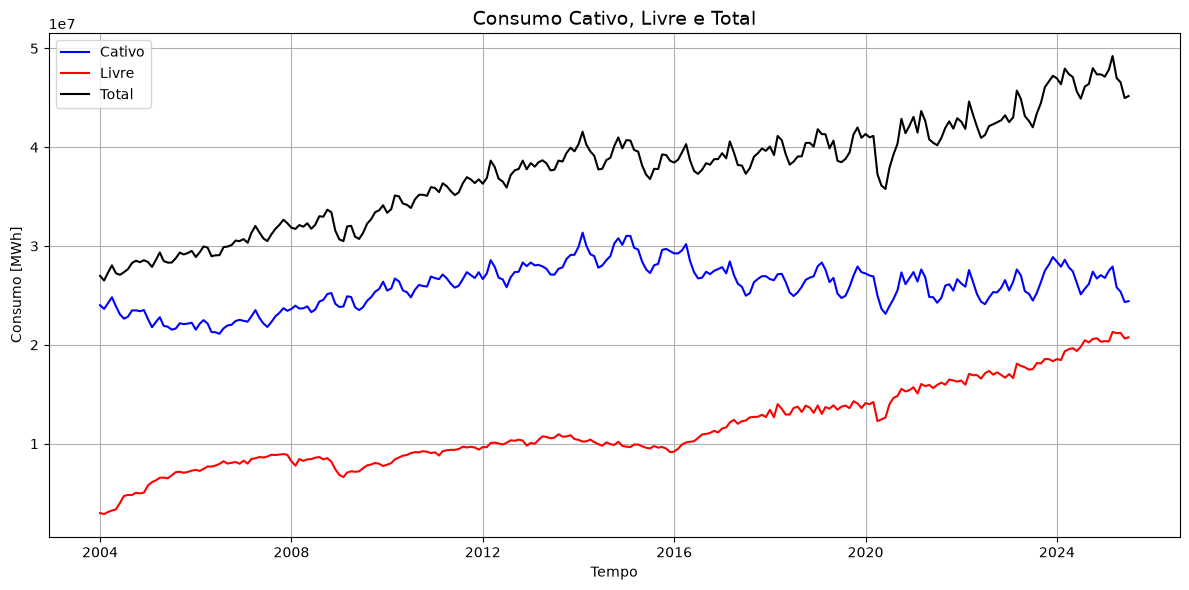

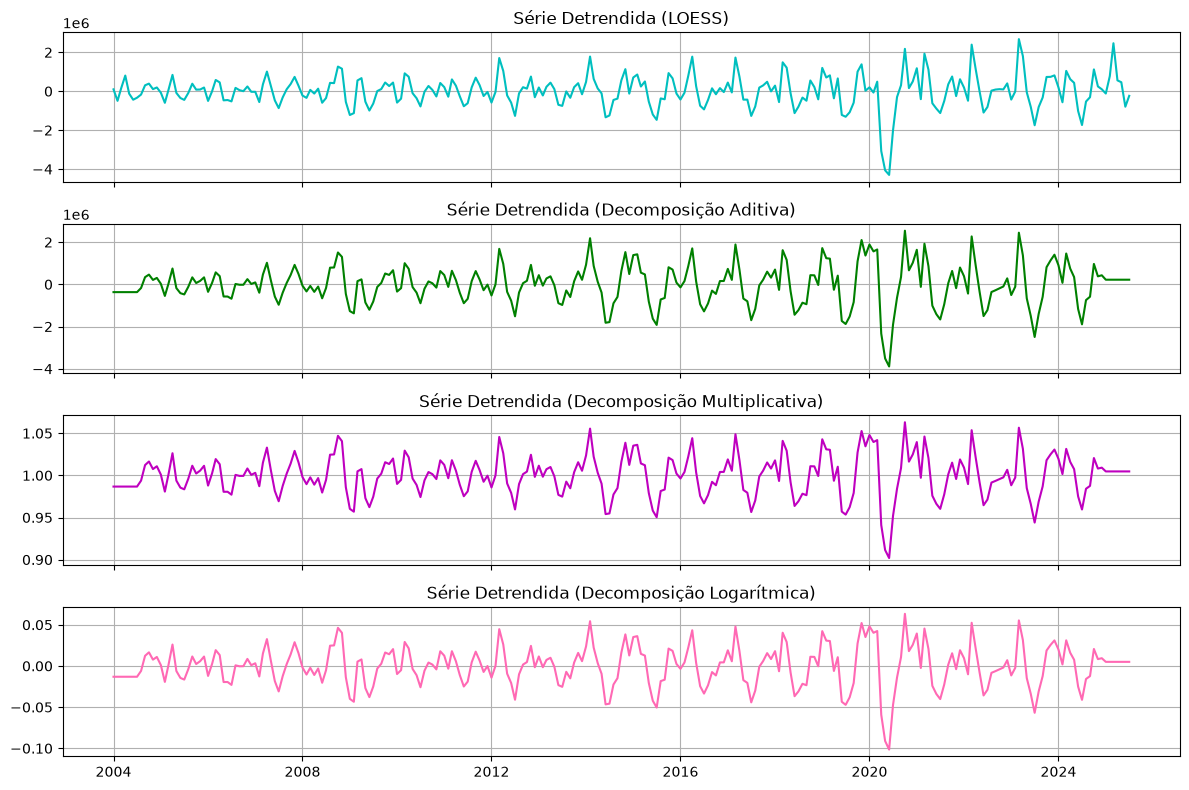

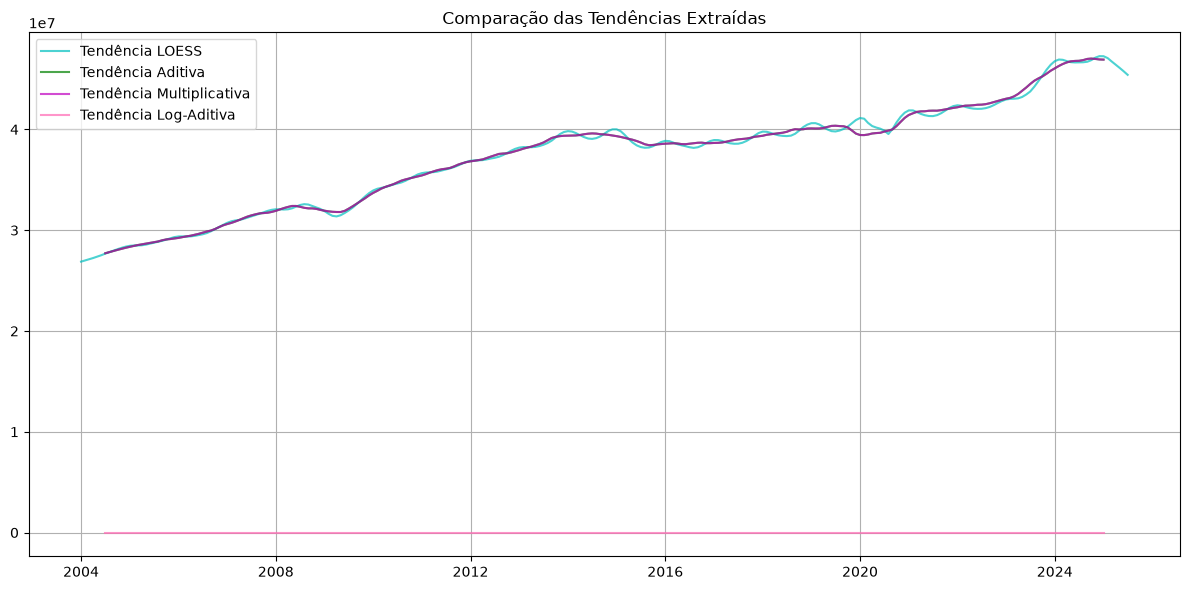

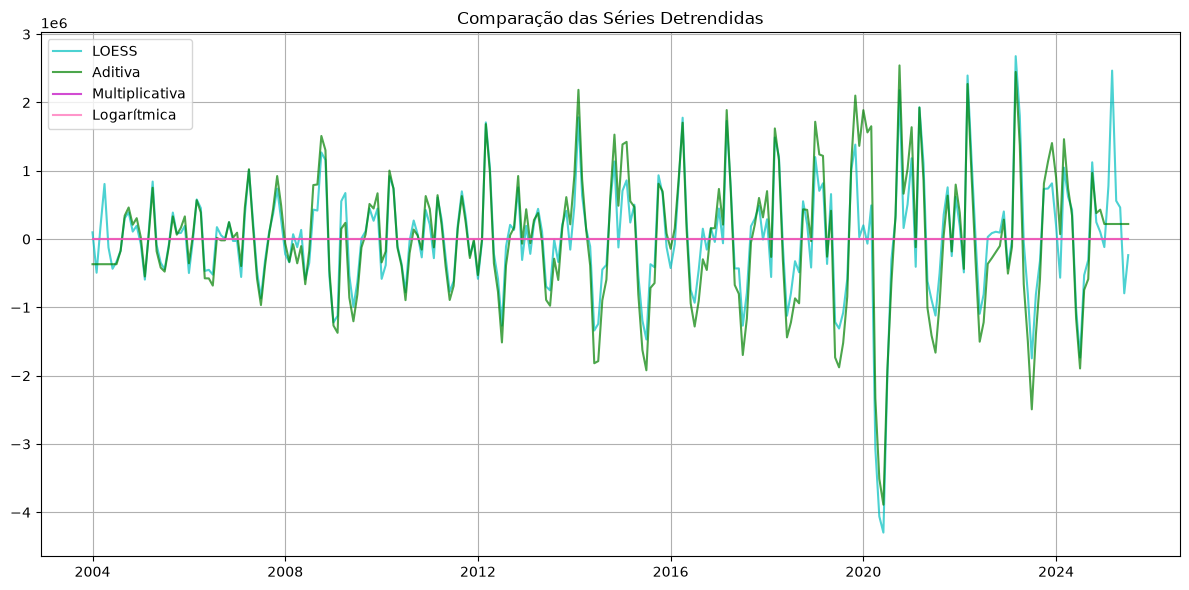

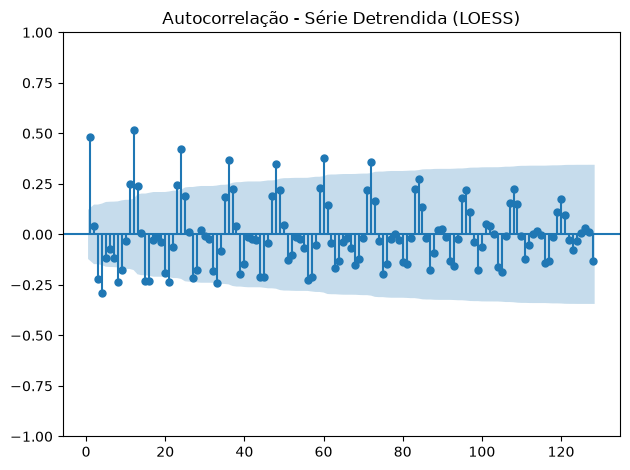

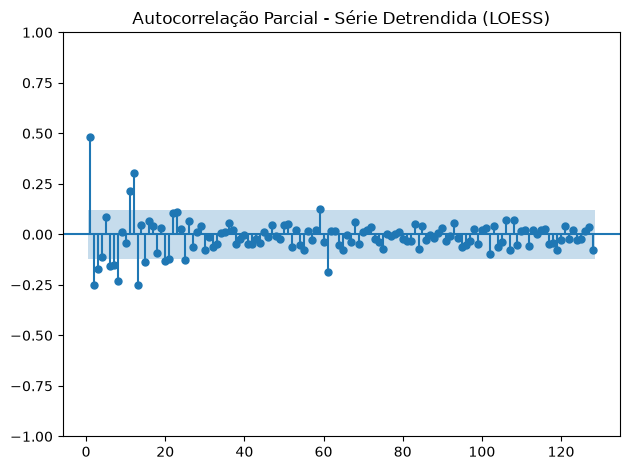

C:\Users\lucas\AppData\Local\Temp\ipykernel_18464\1610384864.py:79: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/np.fft.rfftfreq(N), np.abs(espectro_fourier))


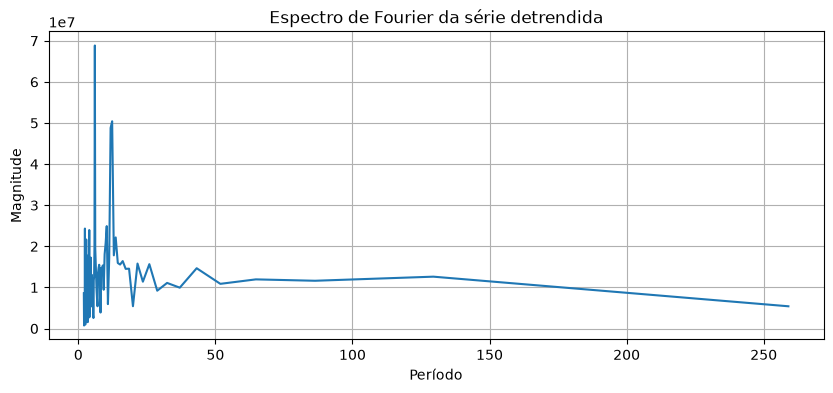

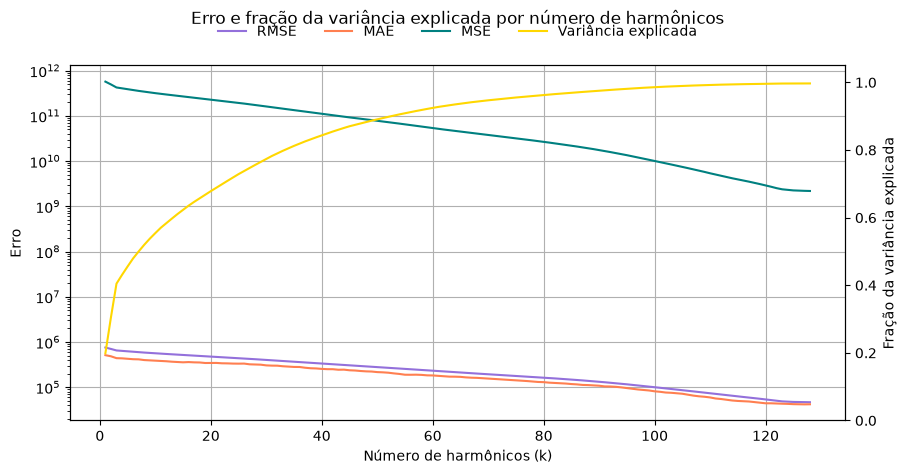

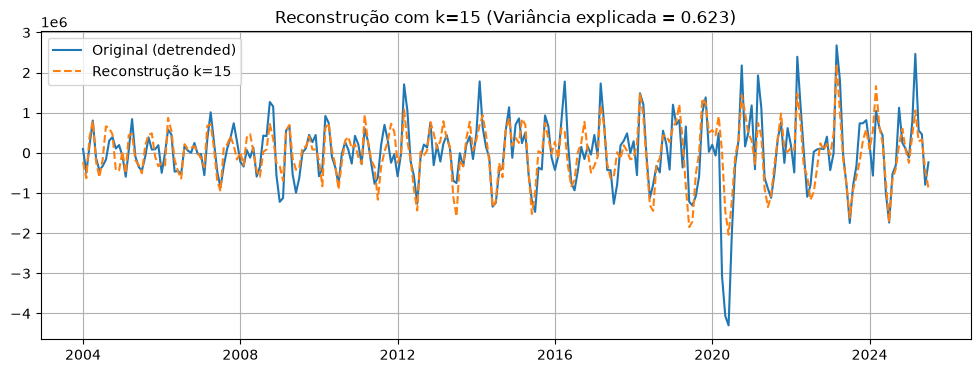

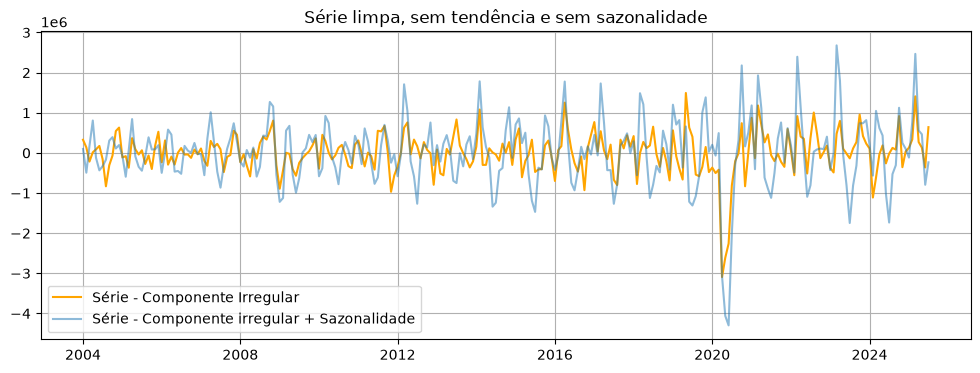

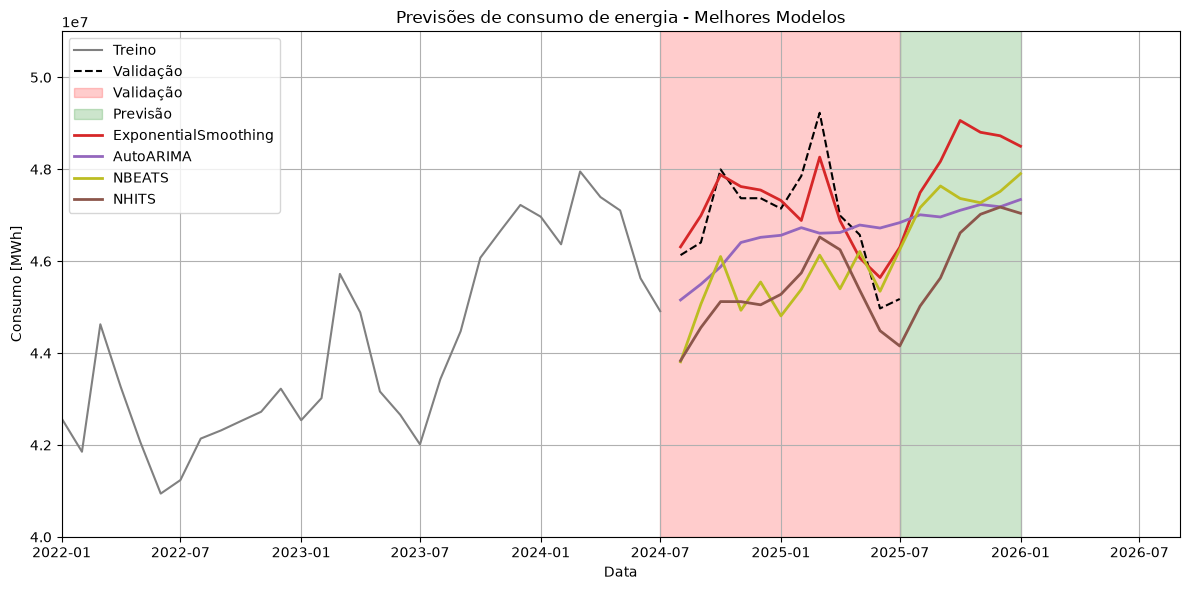

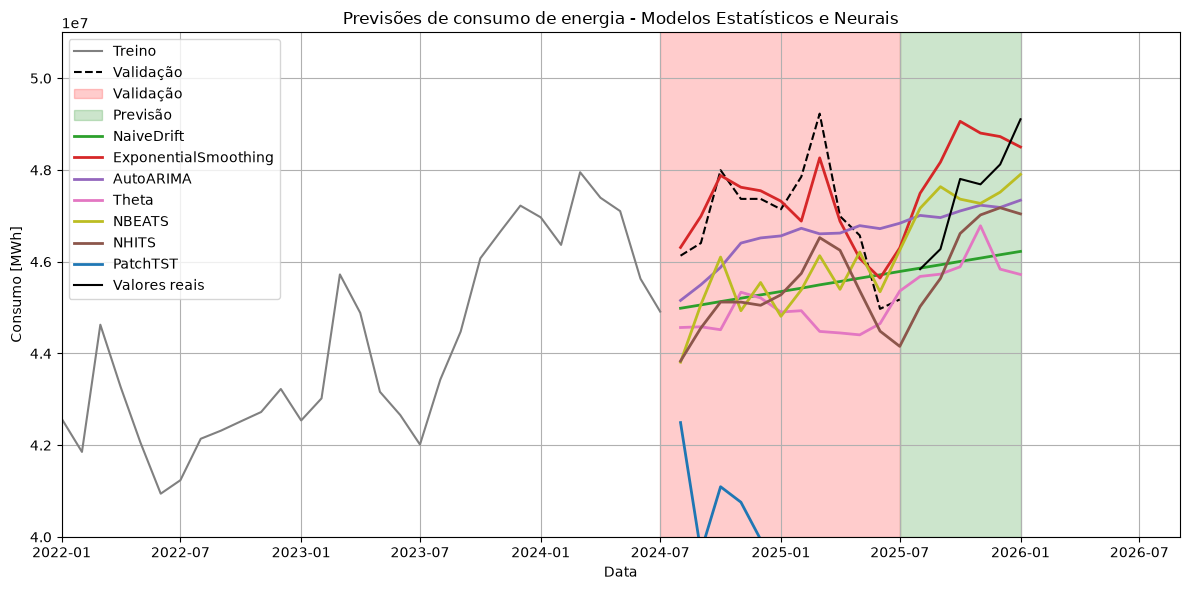

In [6]:
# 1. Garante que a pasta 'graficos' exista no diretório atual
pasta_destino = 'graficos'
os.makedirs(pasta_destino, exist_ok=True)

## Comparação do consumo total, cativo e livre ao longo do tempo
plt.figure(figsize=(12, 6))
plt.plot(df_analise_consumo.index, total_consumo_cativo.replace(0, np.nan).ffill(), label='Cativo', color='b')
plt.plot(df_analise_consumo.index, total_consumo_livre.replace(0, np.nan).ffill(), label='Livre', color='r')
plt.plot(df_analise_consumo.index, total_consumo, label='Total', color='k')
plt.title('Consumo Cativo, Livre e Total', fontsize=14)
plt.xlabel('Tempo')
plt.ylabel('Consumo [MWh]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Consumo_Cativo_Livre_Total.png'), dpi=300)
plt.show()

## 2. Comparação das quatro formas de detrending em subplots
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_analise_consumo.index, df_analise_consumo['detrended_loess'], color='c')
ax[0].set_title('Série Detrendida (LOESS)')
ax[0].grid()
ax[1].plot(df_analise_consumo.index, df_analise_consumo['detrended_aditiva'], color='g')
ax[1].set_title('Série Detrendida (Decomposição Aditiva)')
ax[1].grid()
ax[2].plot(df_analise_consumo.index, df_analise_consumo['detrended_mult'], color='m')
ax[2].set_title('Série Detrendida (Decomposição Multiplicativa)')
ax[2].grid()
ax[3].plot(df_analise_consumo.index, df_analise_consumo['detrended_log'], color='hotpink')
ax[3].set_title('Série Detrendida (Decomposição Logarítmica)')
ax[3].grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Serie_Detrendida.png'), dpi=300)
plt.show() 

## 3. Plot das tendências extraídas pelos métodos
plt.figure(figsize=(12,6))
plt.plot(df_analise_consumo.index, trend_loess, label='Tendência LOESS', color='c', alpha=0.7)
plt.plot(df_analise_consumo.index, decomp_aditiva.trend, label='Tendência Aditiva', color='g', alpha=0.7)
plt.plot(df_analise_consumo.index, decomp_mult.trend, label='Tendência Multiplicativa', color='m', alpha=0.7)
plt.plot(df_analise_consumo.index, decomp_log.trend, label='Tendência Log-Aditiva', color='hotpink', alpha=0.7)
plt.title("Comparação das Tendências Extraídas")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Tendencias_Extraidas.png'), dpi=300)
plt.show()

## 4. Gráfico combinado com as séries detrendidas
plt.figure(figsize=(12,6))
plt.plot(df_analise_consumo.index, df_analise_consumo['detrended_loess'], label='LOESS', color='c', alpha=0.7)
plt.plot(df_analise_consumo.index, df_analise_consumo['detrended_aditiva'], label='Aditiva', color='g', alpha=0.7)
plt.plot(df_analise_consumo.index, df_analise_consumo['detrended_mult'], label='Multiplicativa', color='m', alpha=0.7)
plt.plot(df_analise_consumo.index, df_analise_consumo['detrended_log'], label='Logarítmica', color='hotpink', alpha=0.7)
plt.title("Comparação das Séries Detrendidas")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Comparacao_Series_Detrendidas.png'), dpi=300)
plt.show()

## 5. Plot de Autocorrelação (ACF)
plot_acf(detrended_loess, lags=128, zero=False, alpha=0.05)
plt.title("Autocorrelação - Série Detrendida (LOESS)")
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'ACF_Serie_Detrendida.png'), dpi=300)
plt.show()

## 6. Plot de Autocorrelação Parcial (PACF)
plot_pacf(detrended_loess, lags=128, zero=False, alpha=0.05, method='ywm') 
plt.title("Autocorrelação Parcial - Série Detrendida (LOESS)")
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'PACF_Serie_Detrendida.png'), dpi=300)
plt.show()

## 7. Plot do espectro dos períodos da série de Fourier
plt.figure(figsize=(10,4))
plt.plot(1/np.fft.rfftfreq(N), np.abs(espectro_fourier))
plt.title('Espectro de Fourier da série detrendida')
plt.xlabel('Período')
plt.ylabel('Magnitude')
plt.grid()
plt.savefig(os.path.join(pasta_destino, 'Espectro_Fourier.png'), dpi=300)
plt.show()

## 8. Plot das métricas de erro de Fourier
fig, ax1 = plt.subplots(figsize=(10,5))
l1, = ax1.plot(ks, rmse_arr, label='RMSE', color='mediumpurple')
l2, = ax1.plot(ks, mae_arr, label='MAE', color='coral')
l4, = ax1.plot(ks, mse_arr, label='MSE', color='teal')
ax1.set_xlabel('Número de harmônicos (k)')
ax1.set_ylabel('Erro')
ax1.set_yscale('log')
ax1.grid()
#ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.yaxis.get_offset_text().set_fontsize(10)

ax2 = ax1.twinx()
l3, = ax2.plot(ks, variancia_arr, color='gold', label='Variância explicada')
ax2.set_ylabel('Fração da variância explicada')
ax2.set_ylim(0, 1.05)

lines = [l1, l2, l4, l3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False, fontsize=10)
plt.title('Erro e fração da variância explicada por número de harmônicos', pad=30)
plt.subplots_adjust(top=0.82)
plt.savefig(os.path.join(pasta_destino, 'Erro_Variancia_Fourier.png'), dpi=300)
plt.show()

## 9. Plot da série detrendida com a reconstrução de Fourier
plt.figure(figsize=(12,4))
plt.plot(df_analise_consumo.index, serie_detrendida, label='Original (detrended)')
plt.plot(df_analise_consumo.index, serie_recons_fourier, label=f'Reconstrução k={k_sel}', linestyle='--')
plt.title(f'Reconstrução com k={k_sel} (Variância explicada = {variancia_arr[k_sel-1]:.3f})')
plt.grid()
plt.legend()
plt.savefig(os.path.join(pasta_destino, 'Serie_Reconstruida_Fourier.png'), dpi=300)
plt.show()

## 10. Plot da série sem a tendência e sem a sazonalidade (Componente irregular)
plt.figure(figsize=(12,4))
plt.plot(df_analise_consumo.index, serie_comp_irregular, label='Série - Componente Irregular', color='orange')
plt.plot(df_analise_consumo.index, serie_detrendida, label='Série - Componente irregular + Sazonalidade', alpha=0.5)
plt.title('Série limpa, sem tendência e sem sazonalidade')
plt.grid()
plt.legend()
plt.savefig(os.path.join(pasta_destino, 'Serie_Comp_Irregular.png'), dpi=300)
plt.show()

## 11. Plot final de previsões (Dados de Treino, Validação e Melhores Modelos)
plt.figure(figsize=(12,6))
plt.plot(serie_treino['ds'], serie_treino['y'], label='Treino', color='gray')
plt.plot(previsoes_com_validacao['ds'], previsoes_com_validacao['y'], label='Validação', color='k', linewidth=1.5, linestyle='--')
plt.axvspan(pd.Timestamp('2024-07-01'),pd.Timestamp('2025-07-01'),
    color='red',
    alpha=0.2,
    label='Validação')
plt.axvspan(pd.Timestamp('2025-07-01'),pd.Timestamp('2026-01-01'),
    color='green',
    alpha=0.2,
    label='Previsão')
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:olive', 'tab:brown']
for i, modelo in enumerate(previsoes_darts.columns):
    if modelo in ['unique_id', 'ds', 'y']:
        continue
    if modelo in melhores_modelos:
        plt.plot(previsoes_darts['ds'],
            previsoes_darts[modelo],
            color=cores[i % len(cores)],
            linewidth=2,
            label=modelo
        )
plt.xlim(left=datetime(2022,1,1), right=datetime(2026,9,1))
plt.ylim(bottom=40000000, top=51000000)
plt.legend()
plt.title('Previsões de consumo de energia - Melhores Modelos')
plt.xlabel('Data')
plt.ylabel('Consumo [MWh]')
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Previsoes_Melhores_Modelos.png'), dpi=300)
plt.show()

## 12. Plot final de previsões (Dados de Treino, Validação e Modelos)
plt.figure(figsize=(12,6))
plt.plot(serie_treino['ds'], serie_treino['y'], label='Treino', color='gray')
plt.plot(previsoes_com_validacao['ds'], previsoes_com_validacao['y'], label='Validação', color='k', linewidth=1.5 , linestyle='--')
plt.axvspan(pd.Timestamp('2024-07-01'),pd.Timestamp('2025-07-01'),
    color='red',
    alpha=0.2,
    label='Validação')
plt.axvspan(pd.Timestamp('2025-07-01'),pd.Timestamp('2026-01-01'),
    color='green',
    alpha=0.2,
    label='Previsão')
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:olive', 'tab:brown']
for i, modelo in enumerate(previsoes_darts.columns):
    if modelo not in ['unique_id', 'ds', 'y']:
        plt.plot(previsoes_darts['ds'],
            previsoes_darts[modelo],
            color=cores[i % len(cores)],
            linewidth=2,
            label=modelo
        )

plt.plot(real_data['ds'], real_data['y'], color='k', label='Valores reais')
plt.xlim(left=datetime(2022,1,1), right=datetime(2026,9,1))
plt.ylim(bottom=40000000, top=51000000)
plt.legend()
plt.title('Previsões de consumo de energia - Modelos Estatísticos e Neurais')
plt.xlabel('Data')
plt.ylabel('Consumo [MWh]')
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(pasta_destino, 'Previsoes_Modelos_Estatisticos_Neurais.png'), dpi=300)
plt.show()

Análise Horário de Verão

In [ ]:
# Períodos de vigência do horário de verão no Brasil
periodos = [
    ('2004-11-01', '2005-02-28', estados_horario_verao),
    ('2005-10-01', '2006-02-28', estados_horario_verao),
    ('2006-11-01', '2007-02-28', estados_horario_verao),
    ('2007-10-01', '2008-02-29', estados_horario_verao),
    ('2008-10-01', '2009-02-28', estados_horario_verao),
    ('2009-10-01', '2010-02-28', estados_horario_verao),
    ('2010-10-01', '2011-02-28', estados_horario_verao),
    ('2011-10-01', '2012-02-29', estados_horario_verao + estado_BA),
    ('2012-10-01', '2013-02-28', estados_horario_verao + estado_TO),
    ('2013-10-01', '2014-02-28', estados_horario_verao),
    ('2014-10-01', '2015-02-28', estados_horario_verao),
    ('2015-10-01', '2016-02-29', estados_horario_verao),
    ('2016-10-01', '2017-02-28', estados_horario_verao),
    ('2017-10-01', '2018-02-28', estados_horario_verao),
    ('2018-11-01', '2019-02-28', estados_horario_verao),
]

# DataFrame mensal
datas = pd.date_range('2004-01-01', '2025-07-01', freq='MS')
df_horario_verao = pd.DataFrame(
    0,
    index=datas,
    columns=estados_horario_verao+estados_sem_horario_verao+estado_BA+estado_TO,
    dtype='int8'
)

# Preenche os períodos
for inicio, fim, estados in periodos:
    meses = pd.date_range(inicio, fim, freq='MS')
    for uf in estados:
        df_horario_verao.loc[meses, uf] = 1

print(df_horario_verao.head(20))
print(df_horario_verao.tail())

In [8]:
# Garantindo índice datetime
df_horario_verao.index = pd.to_datetime(df_horario_verao.index)
df_cativo_UF.index = pd.to_datetime(df_cativo_UF.index)
df_livre_UF.index = pd.to_datetime(df_livre_UF.index)
df_consumo_UF.index = pd.to_datetime(df_consumo_UF.index)

# Ajustando nomes das colunas
df_consumo_cativo = df_cativo_UF.copy()
df_consumo_cativo.columns = [c.split("_")[-1] for c in df_consumo_cativo.columns]
df_consumo_livre = df_livre_UF.copy()
df_consumo_livre.columns = [c.split("_")[-1] for c in df_consumo_livre.columns]

# Wide -> Long
df_hv_long = (
    df_horario_verao
    .reset_index()
    .melt(id_vars="index",
          var_name="uf",
          value_name="horario_verao")
    .rename(columns={"index":"data"})
)

df_cons_long_cativo = (
    df_consumo_cativo
    .reset_index()
    .melt(id_vars="index",
          var_name="uf",
          value_name="consumo")
    .rename(columns={"index":"data"})
)

df_cons_long_livre = (
    df_consumo_livre
    .reset_index()
    .melt(id_vars="index",
          var_name="uf",
          value_name="consumo")
    .rename(columns={"index":"data"})
)

df_cons_long_consumo_total = (
    df_consumo_UF
    .reset_index()
    .melt(id_vars="index",
          var_name="uf",
          value_name="consumo")
    .rename(columns={"index":"data"})
)

# Merge
df_cativo = pd.merge(
    df_cons_long_cativo,
    df_hv_long,
    on=["data","uf"],
    how="inner"
)

df_livre = pd.merge(
    df_cons_long_livre,
    df_hv_long,
    on=["data","uf"],
    how="inner"
)

df_consumo_total = pd.merge(
    df_cons_long_consumo_total,
    df_hv_long,
    on=["data","uf"],
    how="inner"
)


# VARIÁVEIS TEMPORAIS
df_cativo["ano"] = df_cativo["data"].dt.year
df_livre["ano"] = df_livre["data"].dt.year
df_consumo_total["ano"] = df_consumo_total["data"].dt.year

df_cativo["mes"] = df_cativo["data"].dt.month
df_livre["mes"] = df_livre["data"].dt.month
df_consumo_total["mes"] = df_consumo_total["data"].dt.month

# somente meses em que existia horário de verão
meses_hv = [10,11,12,1,2]

df_cativo = df_cativo[df_cativo["mes"].isin(meses_hv)].copy()
df_livre = df_livre[df_livre["mes"].isin(meses_hv)].copy()
df_consumo_total = df_consumo_total[df_consumo_total["mes"].isin(meses_hv)].copy()


# ESTADOS TRATADOS
ufs_tratadas = ["RS","SC","PR","SP","RJ","ES","MG","GO","DF","MT","MS"]

df_cativo["tratado"] = (
    df_cativo["uf"]
    .isin(ufs_tratadas)
    .astype(int)
)

df_livre["tratado"] = (
    df_livre["uf"]
    .isin(ufs_tratadas)
    .astype(int)
)

df_consumo_total["tratado"] = (
    df_consumo_total["uf"]
    .isin(ufs_tratadas)
    .astype(int)
)


# PERÍODO PÓS-REVOGAÇÃO
# O primeiro horário de verão cancelado seria o de 2019/2020
df_cativo["pos"] = (
    df_cativo["data"] >= "2019-10-01"
).astype(int)

df_livre["pos"] = (
    df_livre["data"] >= "2019-10-01"
).astype(int)

df_consumo_total["pos"] = (
    df_consumo_total["data"] >= "2019-10-01"
).astype(int)

# DIFERENÇAS-EM-DIFERENÇAS (DiD)

df_cativo["did"] = df_cativo["tratado"] * df_cativo["pos"]
df_cativo["consumo"] = pd.to_numeric(df_cativo["consumo"], errors="coerce")
df_cativo = df_cativo[df_cativo["consumo"] > 0].copy()
df_cativo["log_consumo"] = np.log(df_cativo["consumo"])

df_livre["did"] = df_livre["tratado"] * df_livre["pos"]
df_livre["consumo"] = pd.to_numeric(df_livre["consumo"], errors="coerce")
df_livre = df_livre[df_livre["consumo"] > 0].copy()
df_livre["log_consumo"] = np.log(df_livre["consumo"])

df_consumo_total["did"] = df_consumo_total["tratado"] * df_consumo_total["pos"]
df_consumo_total["consumo"] = pd.to_numeric(df_consumo_total["consumo"], errors="coerce")
df_consumo_total = df_consumo_total[df_consumo_total["consumo"] > 0].copy()
df_consumo_total["log_consumo"] = np.log(df_consumo_total["consumo"])

# MODELO DiD Cativo
modelo_cativo = smf.ols(
    """
    log_consumo ~
    did
    + C(uf)
    + C(ano)
    + C(mes)
    """,
    data=df_cativo
)

resultado_cativo = modelo_cativo.fit(
    cov_type="cluster",
    cov_kwds={
        "groups": df_cativo["uf"]
    }
)

print("Resultados do cativo:")
print(resultado_cativo.summary())

beta_cativo = resultado_cativo.params["did"]
efeito_cativo = (np.exp(beta_cativo)-1)*100


print(f"Efeito estimado do fim do horário de verão: {efeito_cativo:.2f}%")
print(f"P-valor: {resultado_cativo.pvalues['did']:.4f}")


# MODELO DiD livre
modelo_livre = smf.ols(
    """
    log_consumo ~
    did
    + C(uf)
    + C(ano)
    + C(mes)
    """,
    data=df_livre
)

resultado_livre = modelo_livre.fit(
    cov_type="cluster",
    cov_kwds={
        "groups": df_livre["uf"]
    }
)

print("Resultados do livre:")
print(resultado_livre.summary())

beta_livre = resultado_livre.params["did"]
efeito_livre = (np.exp(beta_livre)-1)*100


print(f"Efeito estimado do fim do horário de verão: {efeito_livre:.2f}%")
print(f"P-valor: {resultado_livre.pvalues['did']:.4f}")

# MODELO DiD Consumo totaL
modelo_consumo_total = smf.ols(
    """
    log_consumo ~
    did
    + C(uf)
    + C(ano)
    + C(mes)
    """,
    data=df_consumo_total
)

resultado_consumo_total = modelo_consumo_total.fit(
    cov_type="cluster",
    cov_kwds={
        "groups": df_consumo_total["uf"]
    }
)

print("Resultados do consumo total:")
print(resultado_consumo_total.summary())

beta_consumo_total = resultado_consumo_total.params["did"]
efeito_consumo_total = (np.exp(beta_consumo_total)-1)*100


print(f"Efeito estimado do fim do horário de verão: {efeito_consumo_total:.2f}%")
print(f"P-valor: {resultado_consumo_total.pvalues['did']:.4f}")



Resultados do cativo:
                            OLS Regression Results                            
Dep. Variable:            log_consumo   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 1.461e+05
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.78e-61
Time:                        15:33:17   Log-Likelihood:                 1628.3
No. Observations:                2889   AIC:                            -3151.
Df Residuals:                    2836   BIC:                            -2834.
Df Model:                          52                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         10.8

c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 52, but rank is 26
  warnings.warn('covariance of constraints does not have full '


Resultados do livre:
                            OLS Regression Results                            
Dep. Variable:            log_consumo   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                 3.953e+04
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           9.15e-52
Time:                        15:33:17   Log-Likelihood:                -2107.8
No. Observations:                2484   AIC:                             4320.
Df Residuals:                    2432   BIC:                             4622.
Df Model:                          51                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.53

c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 51, but rank is 25
  warnings.warn('covariance of constraints does not have full '
c:\Users\lucas\Documents\Trabalhos\Data_Science\Portfolio\Series_temporais\Electricity_consumption\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 51, but rank is 25
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:            log_consumo   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 8.853e+04
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           3.84e-56
Time:                        15:33:17   Log-Likelihood:                 1924.7
No. Observations:                2492   AIC:                            -3745.
Df Residuals:                    2440   BIC:                            -3443.
Df Model:                          51                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         10.8326      0.038    287.